**Neural Network**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
x = np.linspace(3,9,1000)

In [ ]:
x

array([3.        , 3.00600601, 3.01201201, 3.01801802, 3.02402402,
       3.03003003, 3.03603604, 3.04204204, 3.04804805, 3.05405405,
       3.06006006, 3.06606607, 3.07207207, 3.07807808, 3.08408408,
       3.09009009, 3.0960961 , 3.1021021 , 3.10810811, 3.11411411,
       3.12012012, 3.12612613, 3.13213213, 3.13813814, 3.14414414,
       3.15015015, 3.15615616, 3.16216216, 3.16816817, 3.17417417,
       3.18018018, 3.18618619, 3.19219219, 3.1981982 , 3.2042042 ,
       3.21021021, 3.21621622, 3.22222222, 3.22822823, 3.23423423,
       3.24024024, 3.24624625, 3.25225225, 3.25825826, 3.26426426,
       3.27027027, 3.27627628, 3.28228228, 3.28828829, 3.29429429,
       3.3003003 , 3.30630631, 3.31231231, 3.31831832, 3.32432432,
       3.33033033, 3.33633634, 3.34234234, 3.34834835, 3.35435435,
       3.36036036, 3.36636637, 3.37237237, 3.37837838, 3.38438438,
       3.39039039, 3.3963964 , 3.4024024 , 3.40840841, 3.41441441,
       3.42042042, 3.42642643, 3.43243243, 3.43843844, 3.44444

In [ ]:
np.random.seed(3)
y = np.sin(x) + np.random.normal(0,0.3,1000)

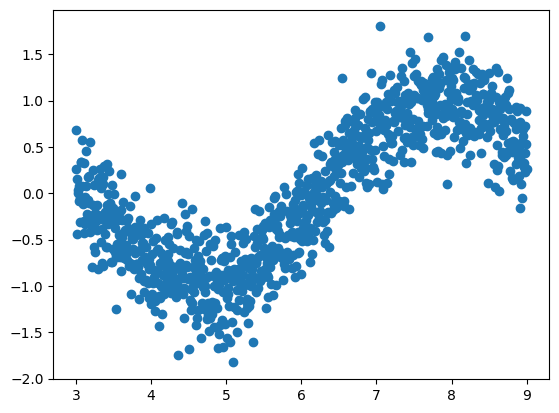

In [ ]:
plt.scatter(x,y)

In [ ]:
from sklearn.neural_network import MLPRegressor

In [ ]:
model = MLPRegressor((100,20))

In [ ]:
xx = x.reshape(-1,1)

In [ ]:
model.fit(xx,y)

MLPRegressor(hidden_layer_sizes=(100, 20))

In [ ]:
yp = model.predict(xx)

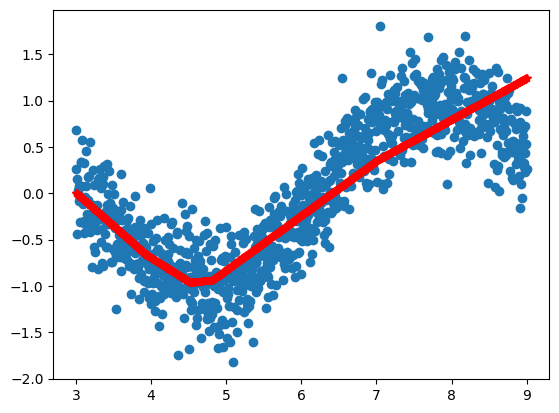

In [ ]:
plt.scatter(xx,y)
plt.plot(x,yp,'*r')

**Logistic Regression**



In [ ]:
from sklearn.datasets import make_moons

In [ ]:
!pip install mglearn --q


In [ ]:
x,y = make_moons(n_samples=1000, noise=0.15, random_state=0)

In [ ]:
x.shape,y.shape

((1000, 2), (1000,))

In [ ]:
import mglearn as mg

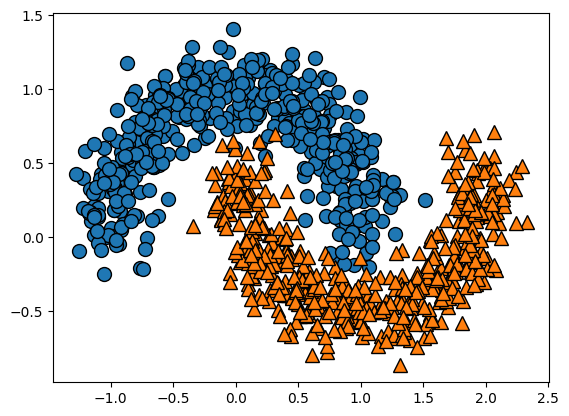

In [ ]:
mg.discrete_scatter(x[:,0],x[:,1],y)

In [ ]:
from sklearn.neural_network import MLPClassifier

In [ ]:
modl = MLPClassifier((1000,200))

In [ ]:
modl.fit(x,y)

MLPClassifier(hidden_layer_sizes=(1000, 200))

In [ ]:
yp = modl.predict(x)

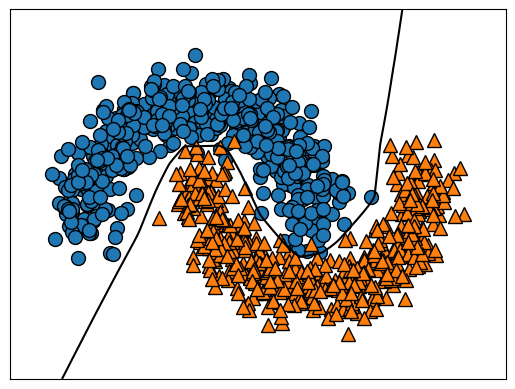

In [ ]:
mg.discrete_scatter(x[:,0],x[:,1],y)
mg.plots.plot_2d_separator(modl,x)

In [ ]:
from sklearn.datasets import make_moons

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
X,Y = make_moons(n_samples=1000, noise=0.15, random_state=0)

In [ ]:
model = nn.Sequential(
    nn.Linear(2,1000),
    nn.ReLU(),
    nn.Linear(1000,2),

    #nn.Sigmoid()
)


In [ ]:
model

Sequential(
  (0): Linear(in_features=2, out_features=1000, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1000, out_features=2, bias=True)
)

In [ ]:
X = torch.FloatTensor(X)
Y = torch.LongTensor(Y)

In [ ]:
model(X)

tensor([[ 0.2510,  0.6954],
        [ 0.2119,  0.5163],
        [-0.0178,  0.1552],
        ...,
        [ 0.1009,  0.1292],
        [ 0.0249,  0.1707],
        [ 0.1212,  0.1808]], grad_fn=<AddmmBackward0>)

In [ ]:
lossfn = nn.CrossEntropyLoss()
sgd_opt = optim.SGD(model.parameters(), lr=0.01)

In [ ]:
Yp = model(X)

In [ ]:
#lossfn(yp, y)

In [ ]:
for _ in range(1000):
  sgd_opt.zero_grad()
  Yp = model(X)
  loss = lossfn(Yp,Y)
  loss.backward()
  sgd_opt.step()
  print(loss.item())
  #logisticRegression_pytorch.ipynb

0.7140699625015259
0.6132500171661377
0.5464655160903931
0.500461757183075
0.4674187898635864
0.4427235722541809
0.4236142039299011
0.40838387608528137
0.39593926072120667
0.38555485010147095
0.3767338991165161
0.3691262900829315
0.36247920989990234
0.35660579800605774
0.35136520862579346
0.3466493487358093
0.34237411618232727
0.3384729027748108
0.3348924219608307
0.33158954977989197
0.3285287022590637
0.32568079233169556
0.3230212330818176
0.3205295205116272
0.3181881010532379
0.31598201394081116
0.3138984739780426
0.3119262158870697
0.3100554645061493
0.30827784538269043
0.3065856993198395
0.30497244000434875
0.30343201756477356
0.30195918679237366
0.3005492091178894
0.2991977334022522
0.2979009747505188
0.29665517807006836
0.2954573333263397
0.29430443048477173
0.2931938171386719
0.2921229898929596
0.29108959436416626
0.2900916635990143
0.2891271710395813
0.28819432854652405
0.2872914969921112
0.2864171266555786
0.2855696678161621
0.284747838973999
0.2839503586292267
0.2831760644912

In [ ]:
Ypred = model(X)

In [ ]:
softout = nn.Softmax(dim=1)(Ypred)

In [ ]:
torch.argmax(softout, dim=1)

tensor([1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0,
        0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
        1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
        1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
        0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
        0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0,
        0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0,
        0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0,
        1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
        0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0,